In [ ]:
# Load necessary libraries
suppressWarnings(library(DESeq2, quiet=T))
suppressWarnings(library(ggplot2, quiet=T))
suppressWarnings(library(pheatmap, quiet=T))
suppressWarnings(library(dplyr, quiet=T))
suppressWarnings(library(reshape2, quiet=T))


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums

In [ ]:
# 1. Load the Count Data and Metadata ---------------------------------------

# Load gene-level count data (assumes gene IDs are in the first column)
count_data <- read.csv(r"\kallisto_output\gene_counts.csv", row.names = 1)
abundance_data <- read.csv(r"\kallisto_output\gene_counts_abundance.csv", row.names = 1)

# Load sample metadata
col_data <- read.csv(r"\Data\SraRunTable.csv", stringsAsFactors = FALSE)
print(colnames(count_data))
print(col_data$Run)


 [1] "SRR7983077" "SRR7983078" "SRR7983079" "SRR7983080" "SRR7983081"
 [6] "SRR7983082" "SRR7983083" "SRR7983084" "SRR7983085" "SRR7983086"
[11] "SRR7983087" "SRR7983088" "SRR7983089" "SRR7983090" "SRR7983091"
[16] "SRR7983092" "SRR7983093" "SRR7983094"
 [1] "SRR7983077" "SRR7983078" "SRR7983079" "SRR7983080" "SRR7983081"
 [6] "SRR7983082" "SRR7983083" "SRR7983084" "SRR7983085" "SRR7983086"
[11] "SRR7983087" "SRR7983088" "SRR7983089" "SRR7983090" "SRR7983091"
[16] "SRR7983092" "SRR7983093" "SRR7983094"


We take abundance_data, to select genes that are low expressed, because each sample's count is normalized to 1 million.

In [29]:
colSums(abundance_data)

SRR7983077 SRR7983078 SRR7983079 SRR7983080 SRR7983081 SRR7983082 SRR7983083 
 1000000.0  1000000.0  1000000.0  1000000.0  1000000.1  1000000.0  1000000.0 
SRR7983084 SRR7983085 SRR7983086 SRR7983087 SRR7983088 SRR7983089 SRR7983090 
  999999.9  1000000.0   999999.9  1000000.0  1000000.1  1000000.0  1000000.0 
SRR7983091 SRR7983092 SRR7983093 SRR7983094 
 1000000.0  1000000.0   999999.9   999999.9

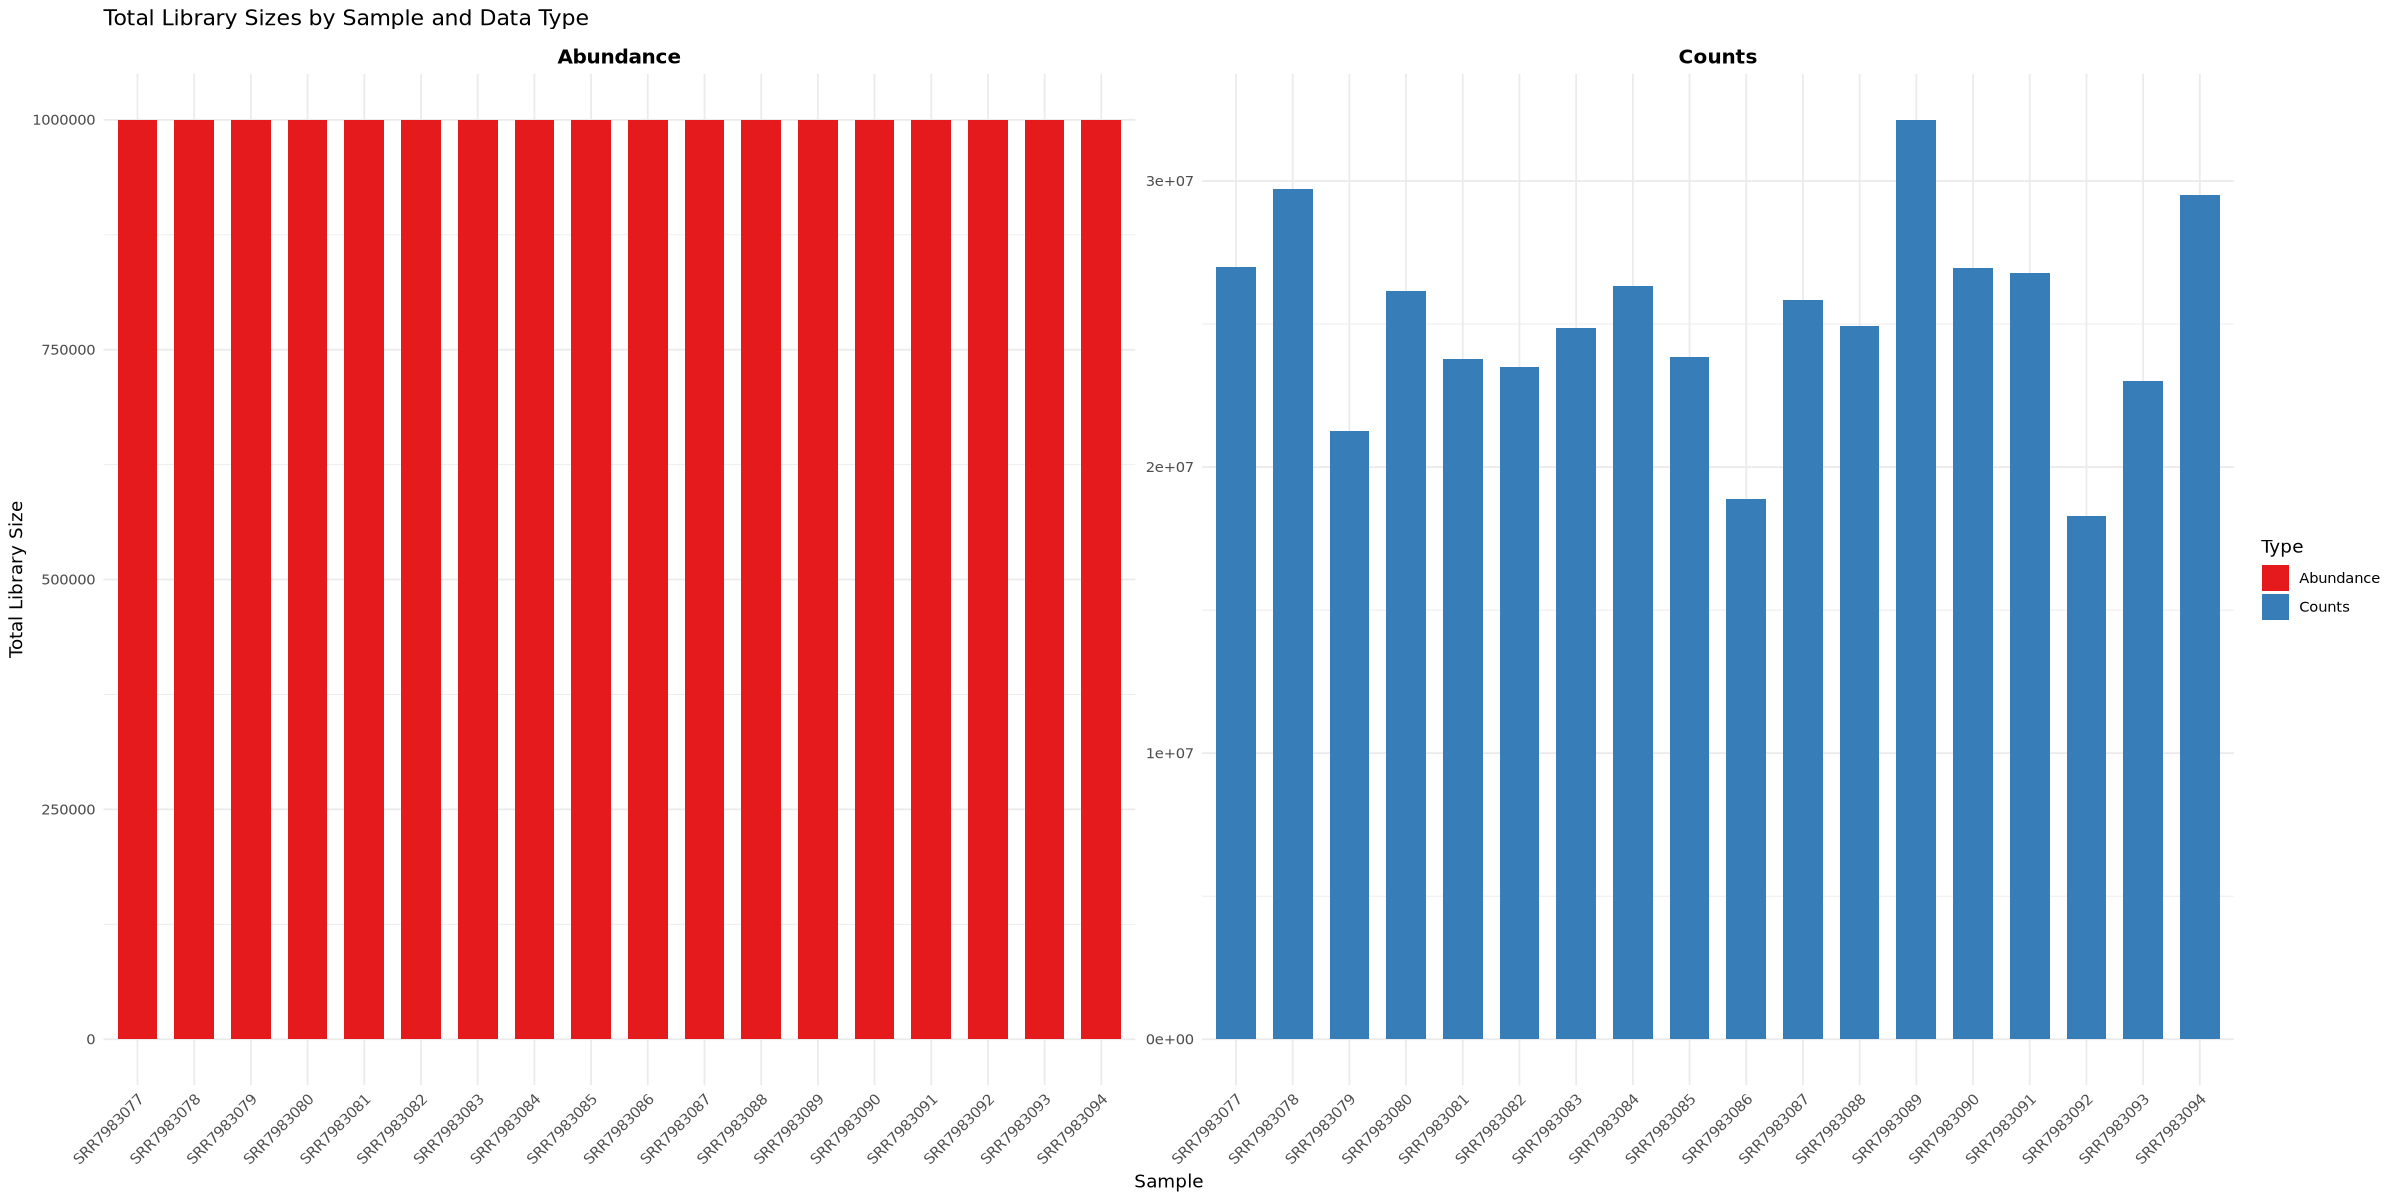

In [30]:
library(ggplot2)

# Calculate library sizes
library_sizes_counts <- colSums(count_data)
library_sizes_abundance <- colSums(abundance_data)

# Create a data frame for plotting
library_sizes_df <- data.frame(
  Sample = rep(colnames(count_data), 2),
  LibrarySize = c(library_sizes_counts, library_sizes_abundance),
  Type = rep(c("Counts", "Abundance"), each = length(library_sizes_counts))
)

# Convert library sizes to integer if they are not already
library_sizes_df$LibrarySize <- as.integer(library_sizes_df$LibrarySize)

options(repr.plot.width = 20, repr.plot.height = 10)

# Create bar plots with facets
p <- ggplot(library_sizes_df, aes(x = Sample, y = LibrarySize, fill = Type)) +
  geom_bar(stat = "identity", position = position_dodge(), width = 0.7) +
  facet_wrap(~ Type, scales = "free_y") +  # Separate facets for Counts and Abundance
  scale_fill_manual(values = c("Abundance" = "#E41A1C", "Counts" = "#377EB8")) +
  labs(title = "Total Library Sizes by Sample and Data Type",
       x = "Sample",
       y = "Total Library Size") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate sample names for readability
        strip.background = element_blank(),
        strip.text.x = element_text(size = 12, color = "black", face = "bold"))

# Print the plot
print(p)


In RNA sequencing (RNA-seq) data analysis, filtering out lowly expressed genes is a crucial preprocessing step before conducting differential expression analysis. This practice enhances the reliability and power of the analysis by reducing noise and the multiple testing burden.

**Rationale for Filtering Lowly Expressed Genes:**

1. **Reduction of Technical Noise:** Genes with low expression levels often exhibit high variability due to technical limitations, making it challenging to distinguish between true biological signals and background noise. Removing these genes helps mitigate the impact of such variability. citeturn0search3

2. **Enhancement of Statistical Power:** Including numerous lowly expressed genes can increase the multiple testing burden, thereby reducing the statistical power to detect truly differentially expressed genes. By filtering out these genes, we can focus on those with sufficient expression levels, improving the sensitivity of the analysis. citeturn0search4

**Use of TPM for Filtering:**

Transcripts Per Million (TPM) is a normalization method that accounts for gene length and sequencing depth, providing a measure of relative abundance of transcripts in the sample. Using TPM values for filtering allows for a more accurate assessment of gene expression levels across samples.

**Implementation in Code:**

In the provided code, the filtering process involves the following steps:

1. **Calculate Mean TPM:** Compute the average TPM value for each gene across all samples.

2. **Define a Threshold:** Set a threshold (e.g., TPM < 1) to identify lowly expressed genes.

3. **Filter Genes:** Remove genes that fall below the defined TPM threshold.

This approach ensures that only genes with sufficient expression levels are retained for downstream differential expression analysis, thereby enhancing the robustness and interpretability of the results.

By implementing such filtering strategies, we can improve the accuracy and reliability of their RNA-seq analyses, leading to more meaningful biological insights. 

In [32]:
# Diagnosis and sanity checks to see if filters work on data reasonably
summary(rowSums(abundance_data > 1))
table(rowSums(abundance_data > 1))


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   1.000   7.351  18.000  18.000 


    0     1     2     3     4     5     6     7     8     9    10    11    12 
26853  1315   902   922   583   566   551   519   473   465   573   448   485 
   13    14    15    16    17    18 
  542   671  2340   770   909 16099 

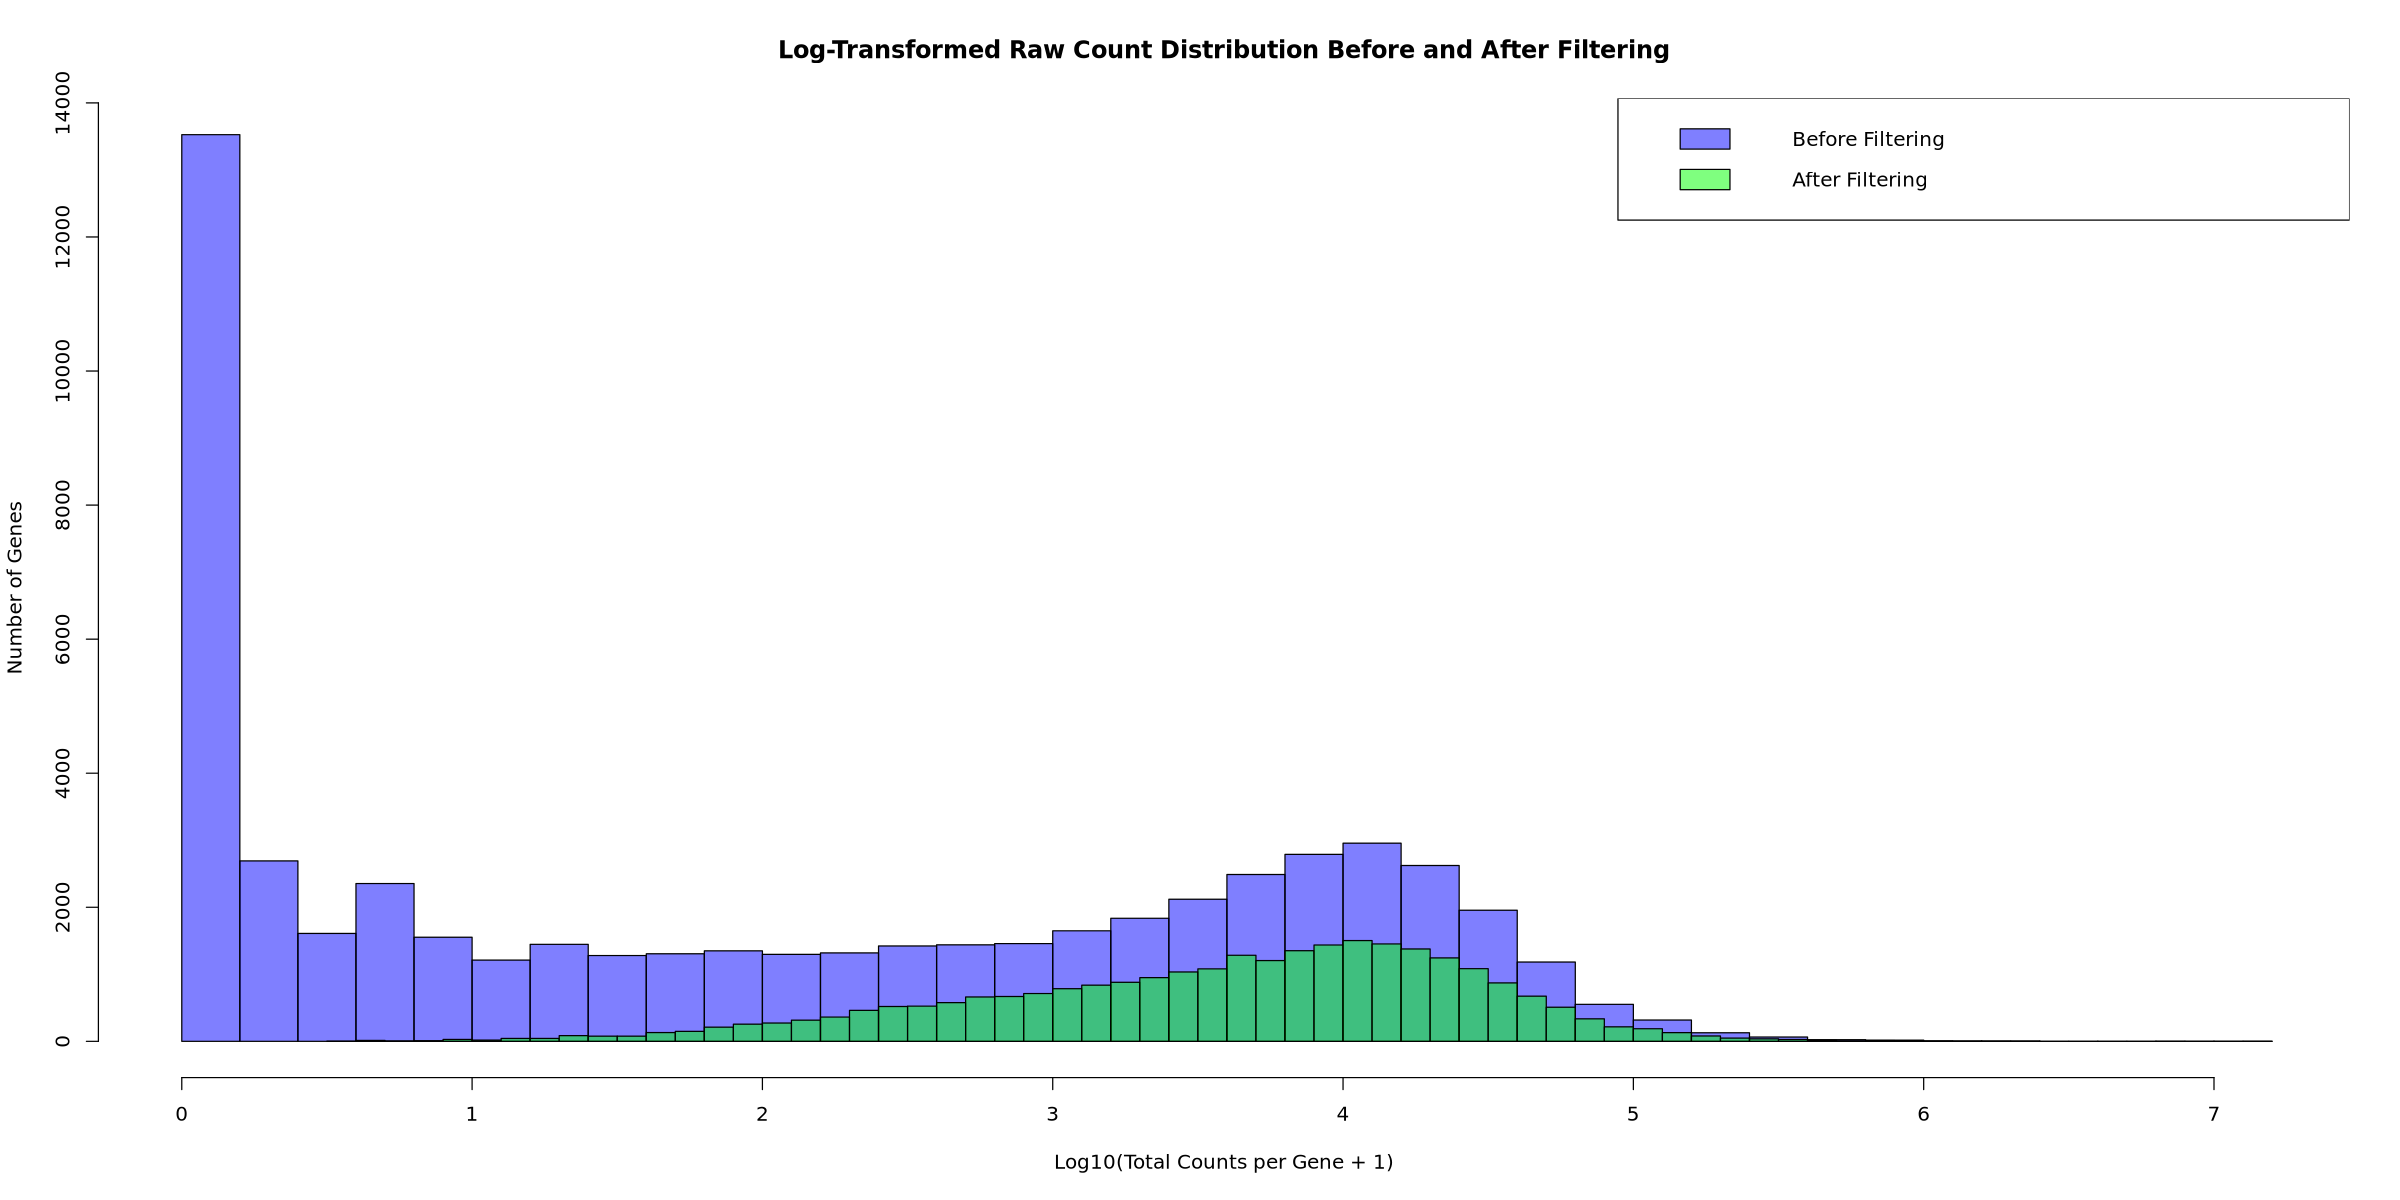

In [33]:
# Main filtering step
# Calculate raw counts before filtering
raw_counts_before <- rowSums(count_data)

# Apply filtering based on TPM
# 'abundance_data' contains TPM values with the same structure as 'count_data'
low_expression_threshold <- 1  # TPM threshold
sample_threshold <- 3  #sample threshold for low expressed genes.

# Main filtering Step
keep_genes <- rowSums(abundance_data > low_expression_threshold) >= sample_threshold
filtered_count_data <- count_data[keep_genes, ]

# Calculate raw counts after filtering
raw_counts_after <- rowSums(filtered_count_data)

# Remove non-finite values before plotting
raw_counts_before <- raw_counts_before[is.finite(log10(raw_counts_before + 1))]
raw_counts_after <- raw_counts_after[is.finite(log10(raw_counts_after + 1))]

# Determine the range for the x-axis
x_range <- range(c(log10(raw_counts_before + 1), log10(raw_counts_after + 1)), na.rm = TRUE)
options(repr.plot.width = 20, repr.plot.height = 10)

# Plot histograms
hist(log10(raw_counts_before + 1), breaks = 50, 
     main = "Log-Transformed Raw Count Distribution Before and After Filtering",
     xlab = "Log10(Total Counts per Gene + 1)", ylab = "Number of Genes", 
     col = rgb(0, 0, 1, 0.5), xlim = x_range)

hist(log10(raw_counts_after + 1), breaks = 50, 
     col = rgb(0, 1, 0, 0.5), add = TRUE)

legend("topright", legend = c("Before Filtering", "After Filtering"),
       fill = c(rgb(0, 0, 1, 0.5), rgb(0, 1, 0, 0.5)))


In [50]:
count_data <- read.csv("/mnt/volume/data/group8/studies/rice/run/kallisto_output/gene_counts.csv", row.names = 1)
# Ensure that the sample names in the metadata match the column names in the count matrix
rownames(col_data) <- col_data$Run
count_data <- count_data[, rownames(col_data), drop = FALSE]

In [51]:
colnames(col_data)

[1] "Run"                            "Assay.Type"                    
 [3] "AvgSpotLen"                     "Bases"                         
 [5] "BioProject"                     "BioSample"                     
 [7] "BioSampleModel"                 "Bytes"                         
 [9] "Center.Name"                    "Consent"                       
[11] "DATASTORE.filetype"             "DATASTORE.provider"            
[13] "DATASTORE.region"               "dev_stage"                     
[15] "ecotype"                        "Experiment"                    
[17] "geo_loc_name_country"           "geo_loc_name_country_continent"
[19] "geo_loc_name"                   "Instrument"                    
[21] "Library.Name"                   "LibraryLayout"                 
[23] "LibrarySelection"               "LibrarySource"                 
[25] "Organism"                       "Platform"                      
[27] "quality..run."                  "ReleaseDate"                   
[29] "replicate"                      "create_date"                   
[31] "version"                        "Sample.Name"                   
[33] "SRA.Study"                      "tissue"

In [ ]:
# design of the study is desing = ~ tissue + dev_stage
col_data$tissue <- factor(col_data$tissue, levels = c("anther-1", "anther-2"))
col_data$dev_stage <- factor(col_data$dev_stage, levels = c("no cold treatment", "2 days cold treatment", "4 days cold treatment"))

In [55]:
# Align 'abundance_data' with 'count_data' to ensure they have the same genes in the same order
common_genes <- intersect(rownames(count_data), rownames(abundance_data))
count_data <- count_data[common_genes, ]
abundance_data <- abundance_data[common_genes, ]

In [56]:
# Identify genes that are expressed above the threshold in at least 3 samples
keep <- rowSums(abundance_data > low_expression_threshold) >= sample_threshold

# Filter 'count_data' to retain only the genes that meet the criteria
count_data <- count_data[keep, ]

# Display the first few rows of the filtered count data
head(count_data)

,SRR7983077,SRR7983078,SRR7983079,SRR7983080,SRR7983081,SRR7983082,SRR7983083,SRR7983084,SRR7983085,SRR7983086,SRR7983087,SRR7983088,SRR7983089,SRR7983090,SRR7983091,SRR7983092,SRR7983093,SRR7983094
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ChrSy.fgenesh.gene.21,20,4,38.000,8,10,6,50.00,71.000,0.000,49,4.000,12,8,20.2511,0,1,2.000,1.000
ChrSy.fgenesh.gene.25,159,136,194.000,336,129,202,128.00,68.000,361.000,63,301.000,342,228,418.0000,52,322,70.000,79.000
ChrSy.fgenesh.gene.26,32,52,22.000,38,27,39,7.00,17.000,47.000,6,52.000,40,18,12.0000,8,12,0.000,0.000
ChrSy.fgenesh.gene.27,1,1,2.000,4,0,1,2.00,1.000,0.000,0,0.000,1,0,2.0000,4,3,11.000,8.000
ChrSy.fgenesh.gene.28,360,494,224.000,542,405,766,842.00,568.000,449.000,425,591.000,382,1052,386.0000,1928,193,2225.000,1845.000
ChrSy.fgenesh.gene.29,491,300,296.064,325,232,199,403.03,573.066,334.301,384,330.025,478,262,312.0000,128,251,196.005,184.079


In [57]:
dim(count_data)

[1] 26916    18

In [ ]:
count_data <- read.csv("/mnt/volume/data/group8/studies/rice/run/kallisto_output/gene_counts.csv", row.names = 1)
# Ensure that the sample names in the metadata match the column names in the count matrix
rownames(col_data) <- col_data$Run
count_data <- count_data[, rownames(col_data), drop = FALSE]

# Split treatment
col_data$inoculation <- ifelse(grepl("^inf", col_data$treatment), "inf", "mock")

# Robust iron parsing (minimal change, no NA)
col_data$iron <- NA_character_
col_data$iron[grepl("\\+Fe", col_data$treatment)] <- "plus"
col_data$iron[grepl("-Fe",  col_data$treatment)] <- "minus"
col_data$iron[grepl("suf",  col_data$treatment)] <- "suf"

# Convert to factors
col_data$inoculation <- factor(col_data$inoculation, levels = c("mock", "inf"))
col_data$iron <- factor(col_data$iron, levels = c("plus", "minus", "suf"))
table(col_data$iron, useNA = "ifany")

# Optional: drop the original column
col_data$treatment <- NULL

# Align 'abundance_data' with 'count_data' to ensure they have the same genes in the same order
common_genes <- intersect(rownames(count_data), rownames(abundance_data))
count_data <- count_data[common_genes, ]
abundance_data <- abundance_data[common_genes, ]

# Identify genes that are expressed above the threshold in at least 3 samples
keep <- rowSums(abundance_data > low_expression_threshold) >= sample_threshold

# Filter 'count_data' to retain only the genes that meet the criteria
count_data <- count_data[keep, ]

# Display the first few rows of the filtered count data
head(count_data)


## DESeq2 Design
The design formula in DESeq2 is crucial as it guides the analysis on how to handle the variables from your metadata when constructing the model for differential expression analysis. The line in question, `DESeqDataSetFromMatrix(countData = filtered_count_data, colData = metadata, design = ~ V1 + V2)`, sets the stage for how DESeq2 will evaluate the relationships between variables. Here are two important steps to consider when designing your DESeq2 analysis:

1. **Contrasting Variables:** The variable listed last in the design formula, in this case, V2, becomes the focal point for contrasts. DESeq2 will use this variable to compare levels (e.g., treatment vs. control) to detect differential expression.
2. **Variance Stabilization:** This transformation step aims to minimize potential technical variance while preserving biological variance essential for accurate modeling. By recalibrating gene expression distributions based on the means within biologically relevant categories specified in the design, this step ensures that the natural variation crucial to the study's biological questions is maintained.

### Understanding DESeq2 Design Operations
The choice of design formula directly influences how the data are interpreted and what biological insights might be derived. Each design option has its context of use:

- **~ V1 + V2**: This model assesses the main effects of V1 and V2 independently, without any interaction between them. It assumes that each variable contributes separately to the gene expression levels, making it ideal for studies where combined effects of variables are not expected.

  **Example**: If V1 represents a treatment (control vs. drug) and V2 represents a genotype (wild type vs. mutant), this design would independently show the effects of treatment and genotype.

- **~ V1 * V2**: This design not only considers the main effects of each variable but also includes their interaction, effectively analyzing whether the impact of one variable could depend on the level of the other. This model is comprehensive and useful in studies where interactions between variables might influence the outcome.

  **Example**: For a study involving the same treatment and genotype, this model would explore not only the separate effects of each but also whether the treatment effect varies by genotype.

- **~ V1:V2**: Focusing solely on the interaction between V1 and V2, this model is used when the interaction itself is of primary interest, assuming no significant main effects of the individual variables. This approach should be used cautiously as it can miss important effects of V1 and V2 alone.

  **Example**: This might be chosen if there is a hypothesis suggesting a unique combined effect of a specific treatment and genotype that is distinct from their individual effects.

### When to Use Each Design
- Use **~ V1 + V2** when expecting independent effects from each variable.
- Use **~ V1 * V2** when exploring both independent and combined effects of the variables.
- Use **~ V1:V2** judiciously, only when the interaction is the sole focus and the main effects are confidently known to be minimal or controlled.

### Practical Tip: Extracting Model Results
After running your DESeq2 analysis, use `resultsNames(dds)` to check the names of the coefficients in your model. This function is crucial for understanding which results correspond to main effects and interactions, especially when you prepare to pull specific contrasts or when you are interpreting the output from more complex designs.


Deseq with development stage and tissues

In [72]:
# Convert filtered count data to integer values
filtered_count_data <- round(filtered_count_data)  # Round values to nearest integer

# Ensure there are no negative values (just in case)
filtered_count_data[filtered_count_data < 0] <- 0

dds <- DESeqDataSetFromMatrix(
  countData = filtered_count_data,
  colData = col_data,
  design = ~ dev_stage + tissue 
)

#Didnt run this run it when i found outlier 
#Remove identified outliers.
#outlier_samples <- c("SRR24364658")
# Keep only samples NOT in outlier list
#keep_samples <- setdiff(colnames(dds), outlier_samples)
#dds <- dds[, keep_samples]

dds$dev_stage <- droplevels(dds$dev_stage)
dds$tissue <- droplevels(dds$tissue)

dds <- DESeq(dds)
# 4. Variance Stabilizing Transformation (VST) ------------------------------

# Apply VST for visualization (PCA and hierarchical clustering)
vsd <- vst(dds, blind = TRUE)


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R.

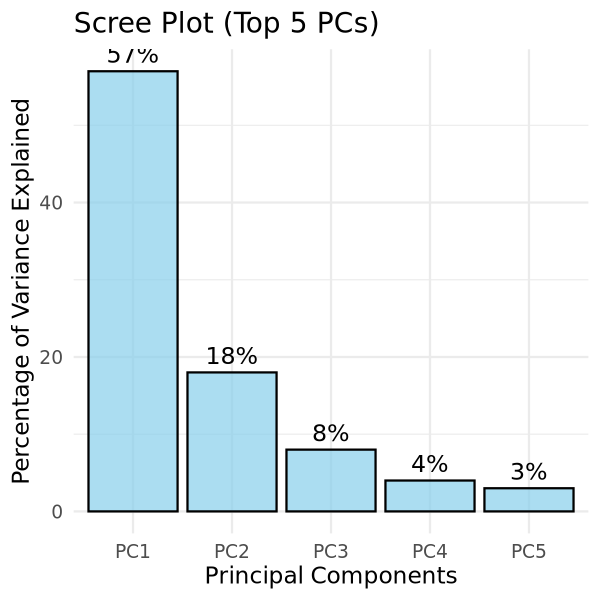

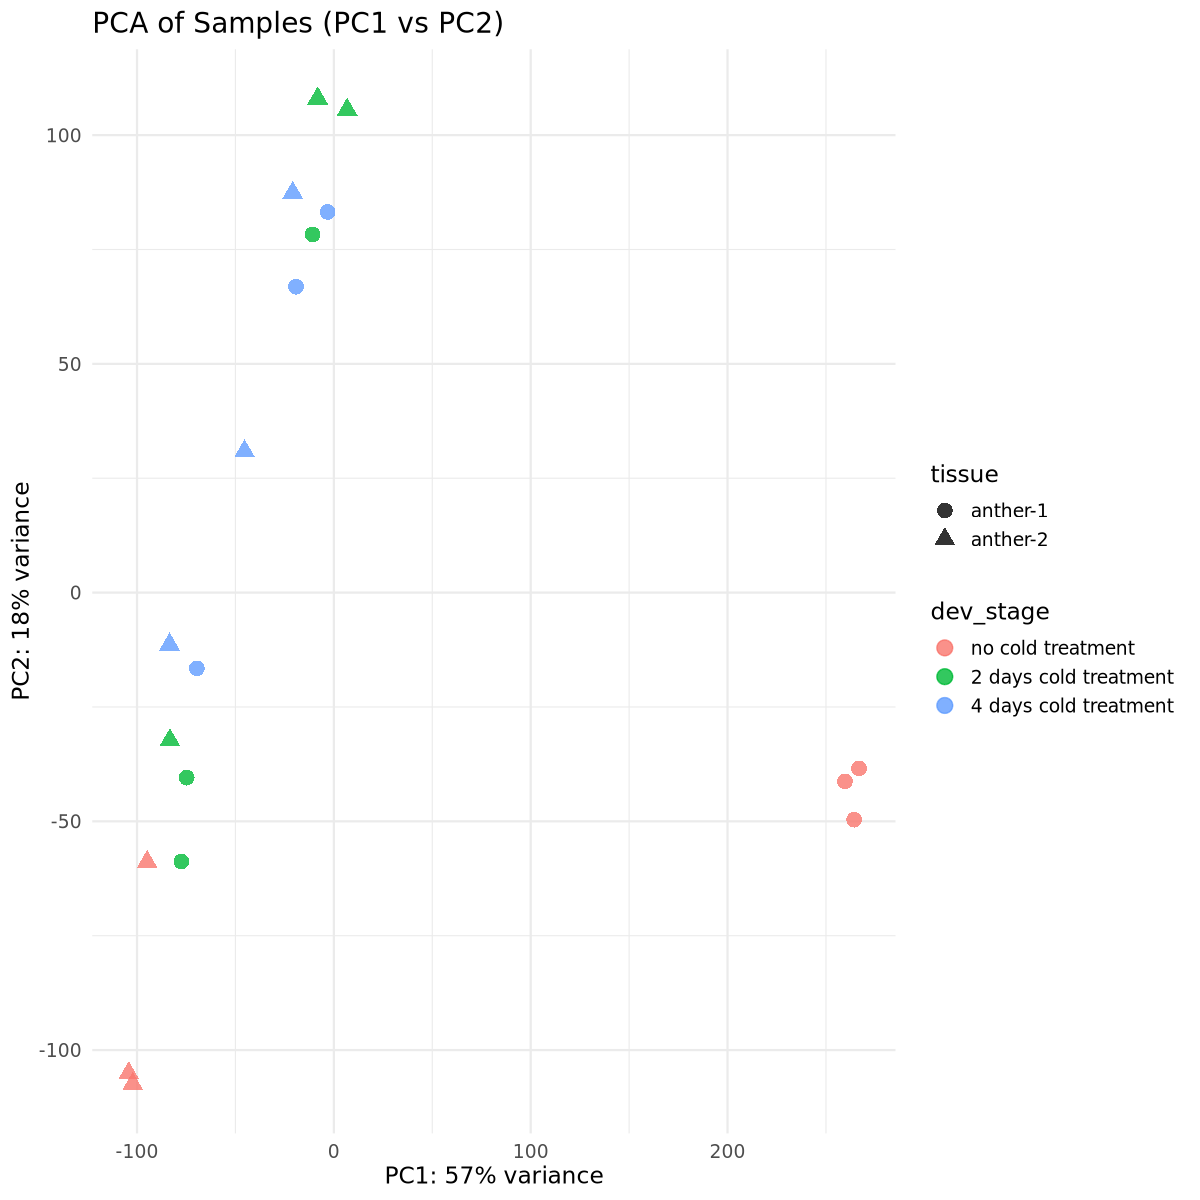

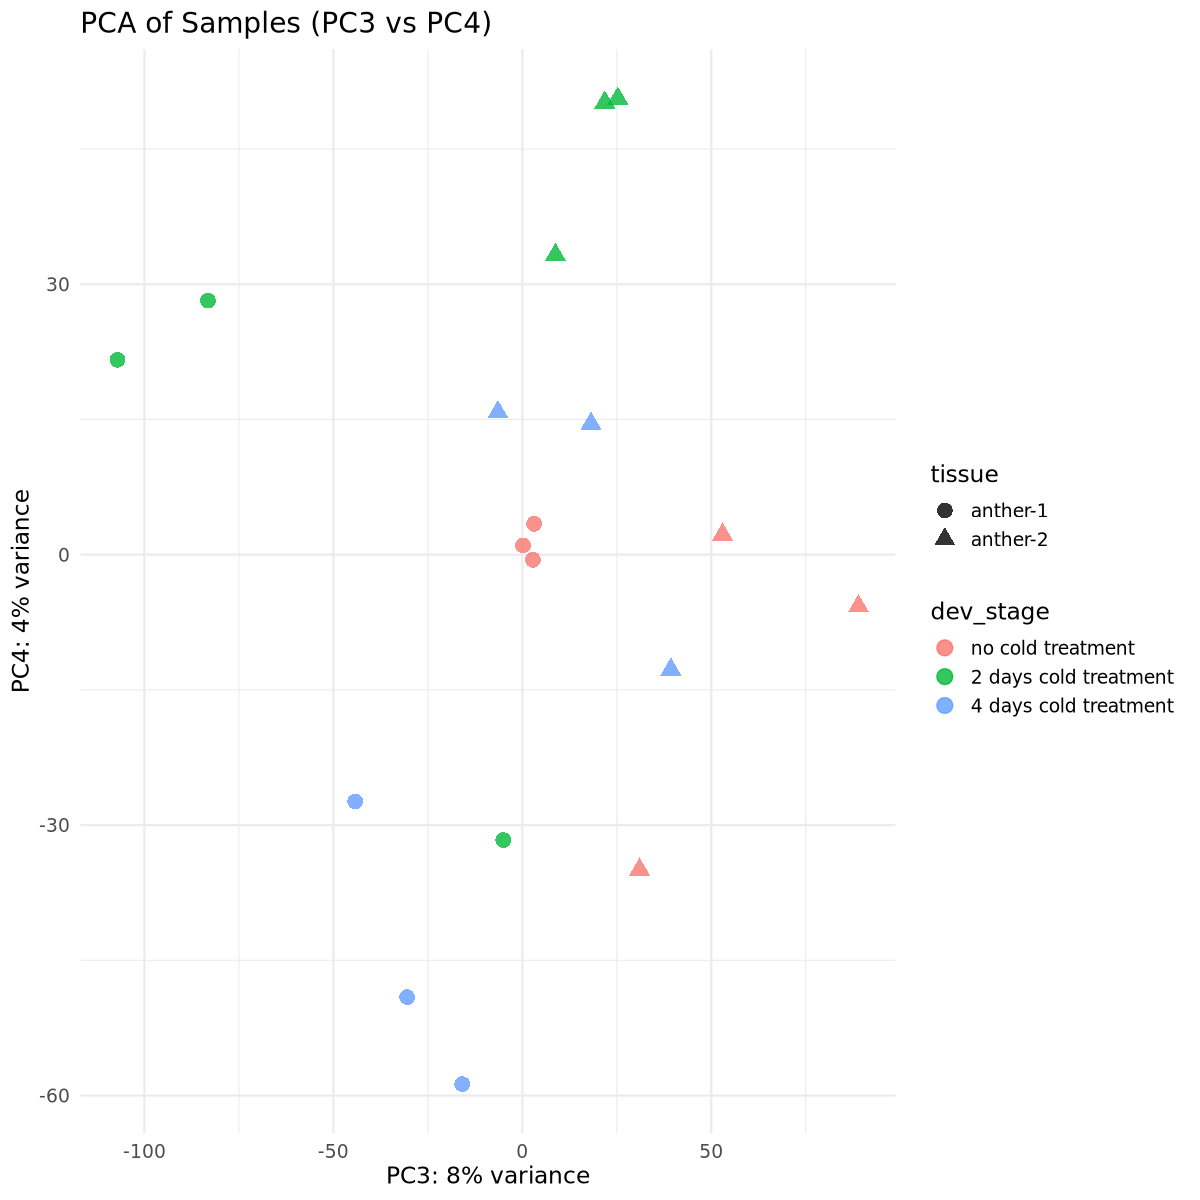

In [73]:
# Perform PCA on the variance-stabilized data (vsd)
pca <- prcomp(t(assay(vsd)))

# Percentage of variance explained
percentVar <- round(100 * (pca$sdev^2 / sum(pca$sdev^2)))

# Scree plot (top 5 PCs)
scree_data <- data.frame(
  PC = paste0("PC", 1:5),
  Variance = percentVar[1:5]
)

options(repr.plot.width = 5, repr.plot.height = 5)

p_scree <- ggplot(scree_data, aes(x = PC, y = Variance)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black", alpha = 0.7) +
  geom_text(aes(label = paste0(Variance, "%")), vjust = -0.5, size = 5) +
  xlab("Principal Components") +
  ylab("Percentage of Variance Explained") +
  ggtitle("Scree Plot (Top 5 PCs)") +
  theme_minimal(base_size = 14)

print(p_scree)

options(repr.plot.width = 10, repr.plot.height = 10)

# PCA data frame (SAFE: metadata from vsd)
pcaData <- as.data.frame(pca$x)
pcaData$dev_stage <- colData(vsd)$dev_stage
pcaData$tissue <- colData(vsd)$tissue

# PC1 vs PC2
p_pca_12 <- ggplot(pcaData, aes(PC1, PC2, color = dev_stage, shape = tissue)) +
  geom_point(size = 4, alpha = 0.8) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  ggtitle("PCA of Samples (PC1 vs PC2)") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

print(p_pca_12)

# PC3 vs PC4
p_pca_34 <- ggplot(pcaData, aes(PC3, PC4, color = dev_stage, shape = tissue)) +
  geom_point(size = 4, alpha = 0.8) +
  xlab(paste0("PC3: ", percentVar[3], "% variance")) +
  ylab(paste0("PC4: ", percentVar[4], "% variance")) +
  ggtitle("PCA of Samples (PC3 vs PC4)") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

print(p_pca_34)

Deseq with only development stage 

In [77]:
#Convert filtered count data to integer values
filtered_count_data <- round(filtered_count_data)  # Round values to nearest integer

# Ensure there are no negative values (just in case)
filtered_count_data[filtered_count_data < 0] <- 0

dds <- DESeqDataSetFromMatrix(
  countData = filtered_count_data,
  colData = col_data,
  design = ~ dev_stage  
)

#Didnt run this run it when i found outlier 
#Remove identified outliers.
#outlier_samples <- c("SRR24364658")
# Keep only samples NOT in outlier list
#keep_samples <- setdiff(colnames(dds), outlier_samples)
#dds <- dds[, keep_samples]

dds$dev_stage <- droplevels(dds$dev_stage)
#dds$tissue <- droplevels(dds$tissue)

dds <- DESeq(dds)
# 4. Variance Stabilizing Transformation (VST) ------------------------------

# Apply VST for visualization (PCA and hierarchical clustering)
vsd_dev <- vst(dds, blind = TRUE)

converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors



  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



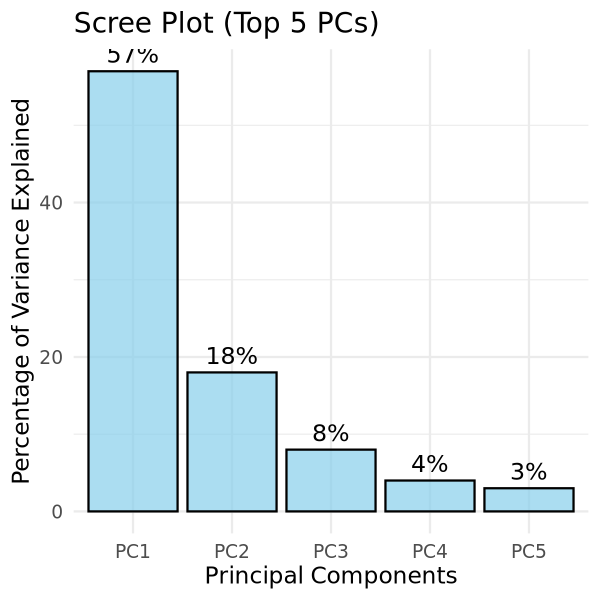

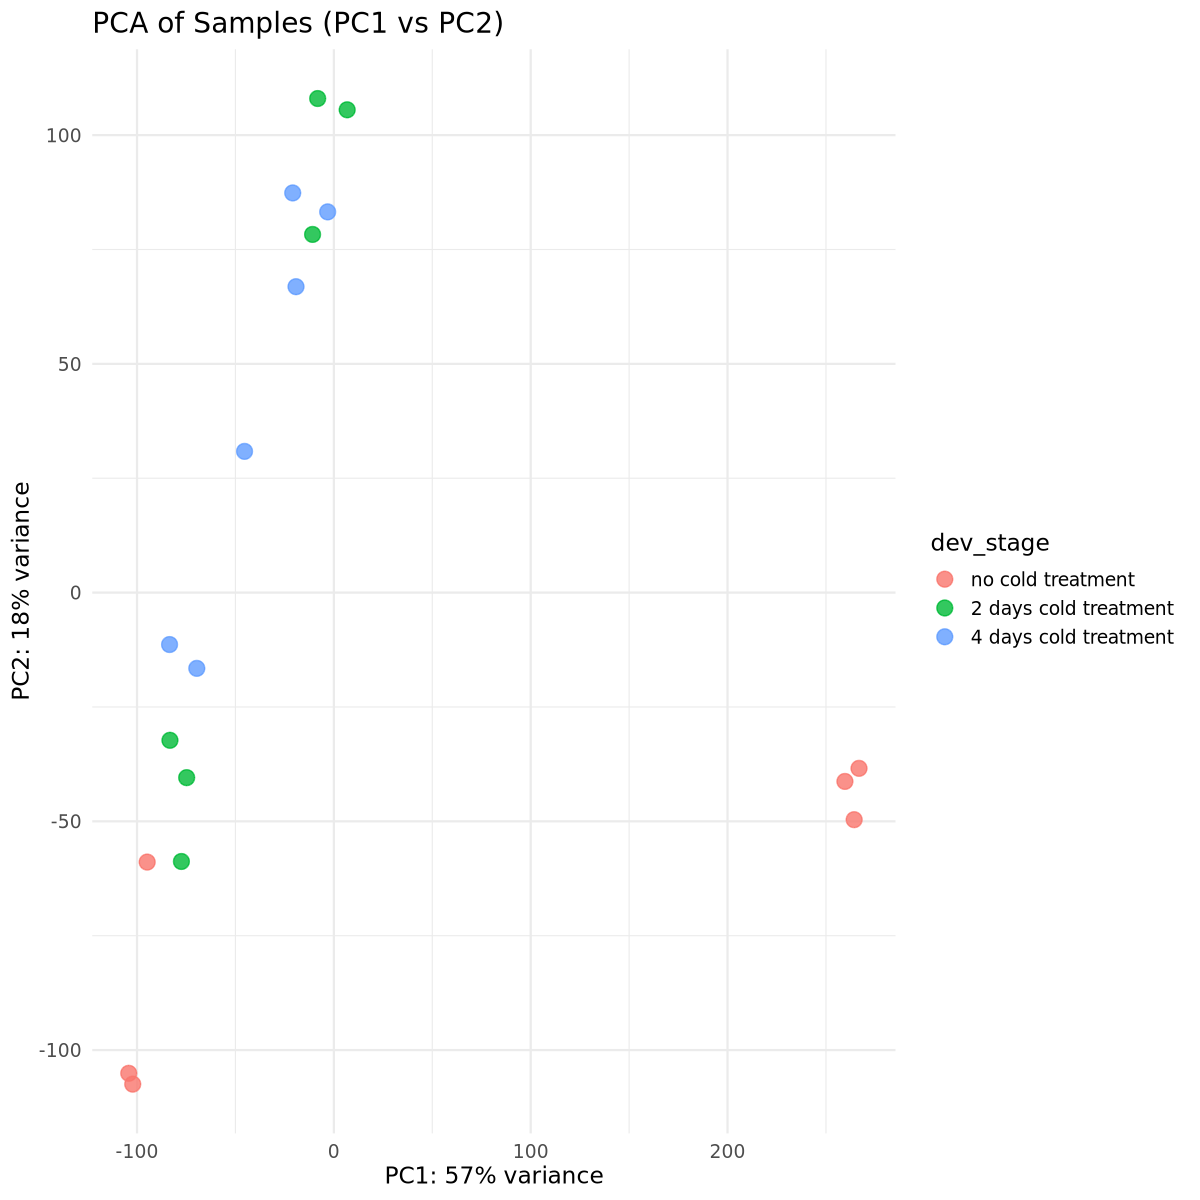

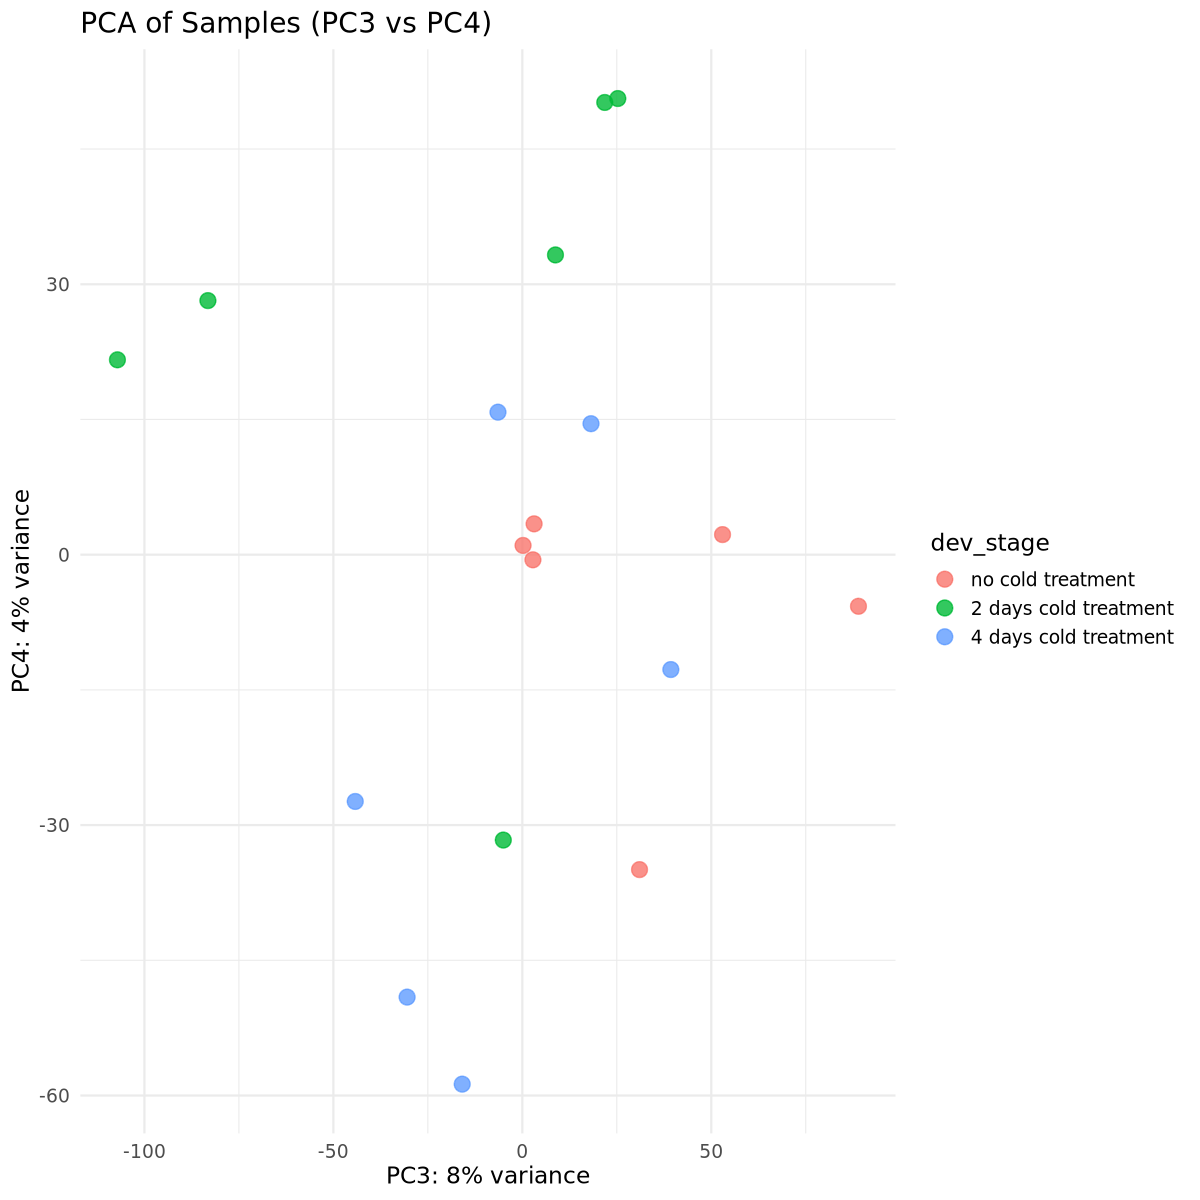

In [78]:
# Perform PCA on the variance-stabilized data (vsd)
pca <- prcomp(t(assay(vsd_dev)))

# Percentage of variance explained
percentVar <- round(100 * (pca$sdev^2 / sum(pca$sdev^2)))

# Scree plot (top 5 PCs)
scree_data <- data.frame(
  PC = paste0("PC", 1:5),
  Variance = percentVar[1:5]
)

options(repr.plot.width = 5, repr.plot.height = 5)

p_scree <- ggplot(scree_data, aes(x = PC, y = Variance)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "black", alpha = 0.7) +
  geom_text(aes(label = paste0(Variance, "%")), vjust = -0.5, size = 5) +
  xlab("Principal Components") +
  ylab("Percentage of Variance Explained") +
  ggtitle("Scree Plot (Top 5 PCs)") +
  theme_minimal(base_size = 14)

print(p_scree)

options(repr.plot.width = 10, repr.plot.height = 10)

# PCA data frame (SAFE: metadata from vsd)
pcaData <- as.data.frame(pca$x)
pcaData$dev_stage <- colData(vsd_dev)$dev_stage
#pcaData$tissue <- colData(vsd)$tissue

# PC1 vs PC2
p_pca_12 <- ggplot(pcaData, aes(PC1, PC2, color = dev_stage)) +
  geom_point(size = 4, alpha = 0.8) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  ggtitle("PCA of Samples (PC1 vs PC2)") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

print(p_pca_12)

# PC3 vs PC4
p_pca_34 <- ggplot(pcaData, aes(PC3, PC4, color = dev_stage)) +
  geom_point(size = 4, alpha = 0.8) +
  xlab(paste0("PC3: ", percentVar[3], "% variance")) +
  ylab(paste0("PC4: ", percentVar[4], "% variance")) +
  ggtitle("PCA of Samples (PC3 vs PC4)") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

print(p_pca_34)

In [67]:
# 5b. Hierarchical Clustering
library(pheatmap)
sample_dists <- dist(t(assay(vsd)))
sample_dist_matrix <- as.matrix(sample_dists)
sample_dist_matrix[0:5,0:5]

,SRR7983077,SRR7983078,SRR7983079,SRR7983080,SRR7983081
SRR7983077,0.00000,153.6833,86.31454,120.2996,176.3746
SRR7983078,153.68325,0.0000,180.12709,127.3830,119.3190
SRR7983079,86.31454,180.1271,0.00000,134.3227,188.3435
SRR7983080,120.29957,127.3830,134.32269,0.0000,144.0097
SRR7983081,176.37459,119.3190,188.34353,144.0097,0.0000


In [68]:
colnames(col_data)

[1] "Run"                            "Assay.Type"                    
 [3] "AvgSpotLen"                     "Bases"                         
 [5] "BioProject"                     "BioSample"                     
 [7] "BioSampleModel"                 "Bytes"                         
 [9] "Center.Name"                    "Consent"                       
[11] "DATASTORE.filetype"             "DATASTORE.provider"            
[13] "DATASTORE.region"               "dev_stage"                     
[15] "ecotype"                        "Experiment"                    
[17] "geo_loc_name_country"           "geo_loc_name_country_continent"
[19] "geo_loc_name"                   "Instrument"                    
[21] "Library.Name"                   "LibraryLayout"                 
[23] "LibrarySelection"               "LibrarySource"                 
[25] "Organism"                       "Platform"                      
[27] "quality..run."                  "ReleaseDate"                   
[29] "replicate"                      "create_date"                   
[31] "version"                        "Sample.Name"                   
[33] "SRA.Study"                      "tissue"

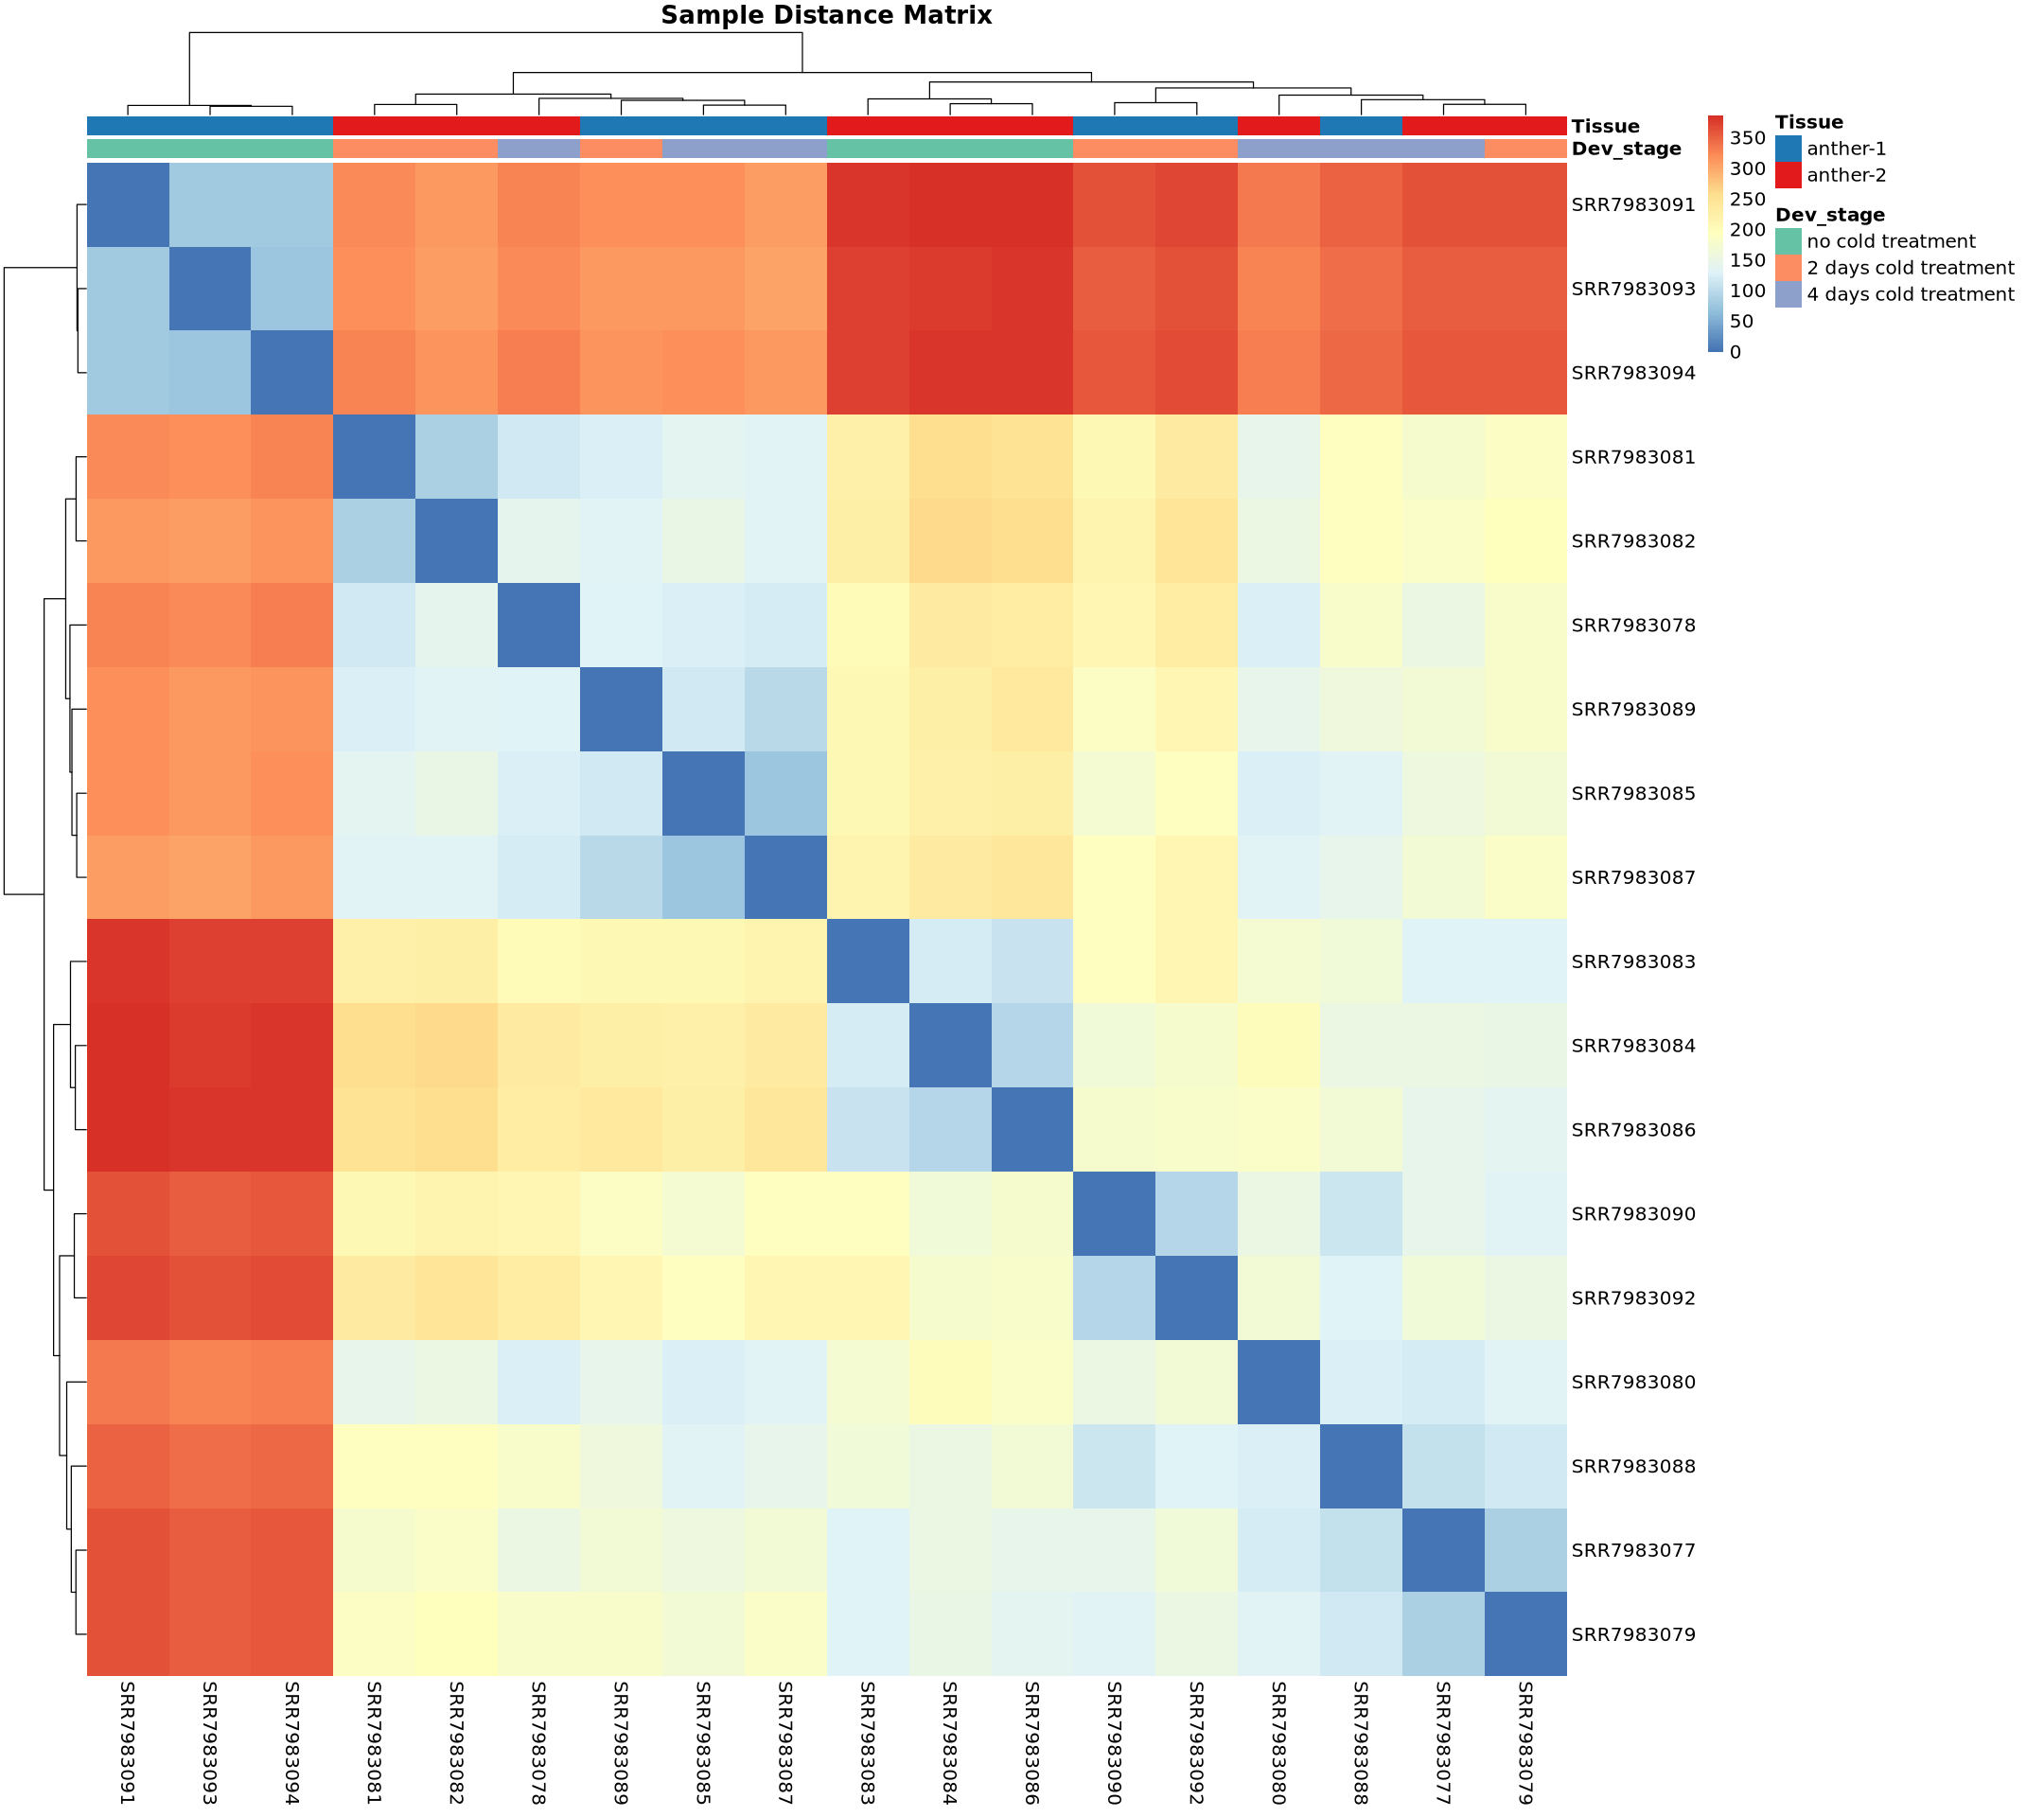

In [83]:
# Define sample names from the distance matrix
sample_names <- colnames(sample_dist_matrix)

# Extract 'inoculation' and 'iron' annotations using SRR IDs
annotations <- data.frame(
  Dev_stage = col_data[sample_names, "dev_stage"],
  Tissue = col_data[sample_names, "tissue"]
)

# Ensure row names of annotations match those in the distance matrix
rownames(annotations) <- sample_names

# Make sure columns are factors
annotations$Dev_stage <- factor(annotations$Dev_stage)
annotations$Tissue <- factor(annotations$Tissue)

# Levels
Dev_stage_levels <- levels(annotations$Dev_stage)
Tissue_levels <- levels(annotations$Tissue)

# Colors must match number of levels exactly
Dev_stage_colors <- setNames(c("#66c2a5", "#fc8d62", "#8da0cb"), Dev_stage_levels)
Tissue_colors <- setNames(c("#1f78b4", "#e31a1c"), Tissue_levels)

# Combine color definitions into a list for pheatmap
annotation_colors <- list(
  Dev_stage = Dev_stage_colors,
  Tissue = Tissue_colors
)

# Increase the plot size for Jupyter Notebook output
options(repr.plot.width = 18, repr.plot.height = 16)

# Plotting the heatmap 
pheatmap(sample_dist_matrix,
         annotation_col = annotations,
         annotation_colors = annotation_colors,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         main = "Sample Distance Matrix",
         fontsize = 12,
         border_color = NA)


In [84]:
resultsNames(dds)

[1] "Intercept"                                           
[2] "dev_stage_2.days.cold.treatment_vs_no.cold.treatment"
[3] "dev_stage_4.days.cold.treatment_vs_no.cold.treatment"

[1] "Intercept"                                           
[2] "dev_stage_2.days.cold.treatment_vs_no.cold.treatment"
[3] "dev_stage_4.days.cold.treatment_vs_no.cold.treatment"

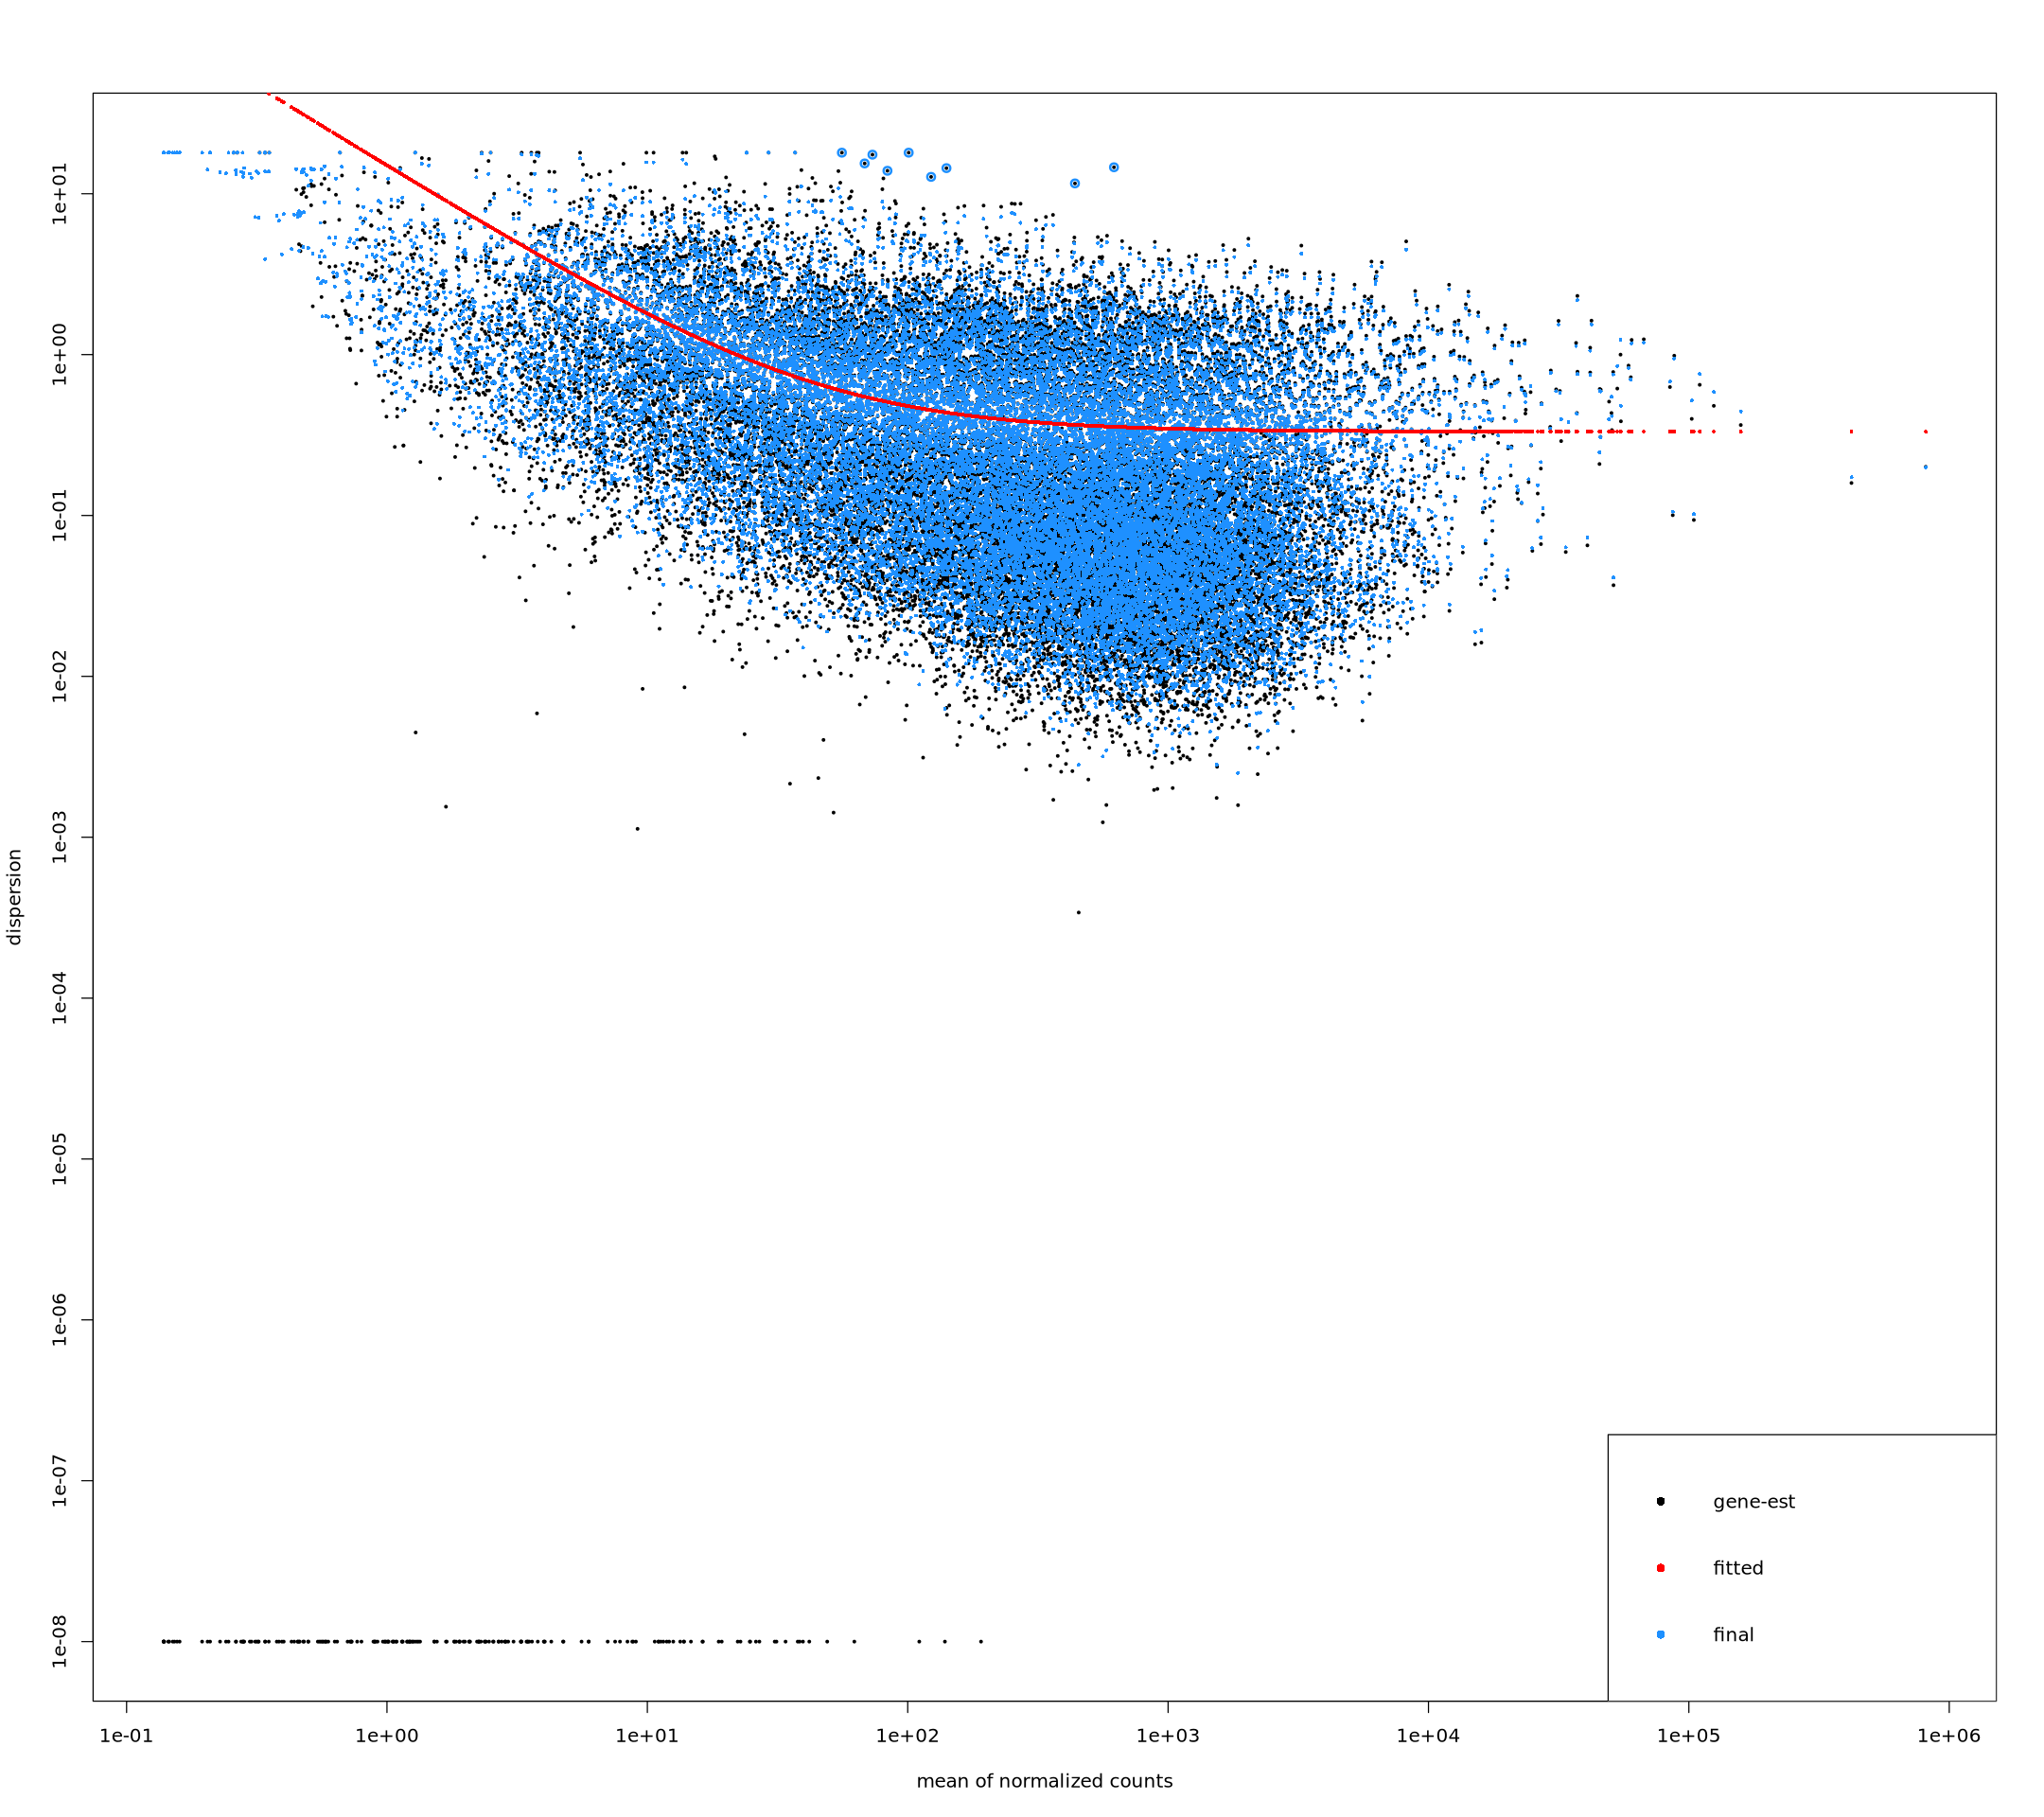

In [87]:
# 6. Extract Differential Expression Results --------------------------------

# Show all available DESeq2 result coefficients
resultsNames(dds)

# Get the DESeq2 results (log2 fold change, p-values, adjusted p-values)
res <- results(dds, name = "dev_stage_4.days.cold.treatment_vs_no.cold.treatment")
# Sort results by p-value (optional)
res <- res[order(res$pvalue), ]

# Filter results based on log fold change (e.g., absolute log2 fold change > 1)
res_filtered <- res[!is.na(res$log2FoldChange) & !is.na(res$padj) & 
                    abs(res$log2FoldChange) > 1 & res$padj < 0.05, ]

# Save the filtered results to a CSV file
write.csv(as.data.frame(res_filtered), file = "../../runs/FunCourse/deseq2_day4_filtered_results.csv")

# 7. Dispersion Plot --------------------------------------------------------

plotDispEsts(dds)

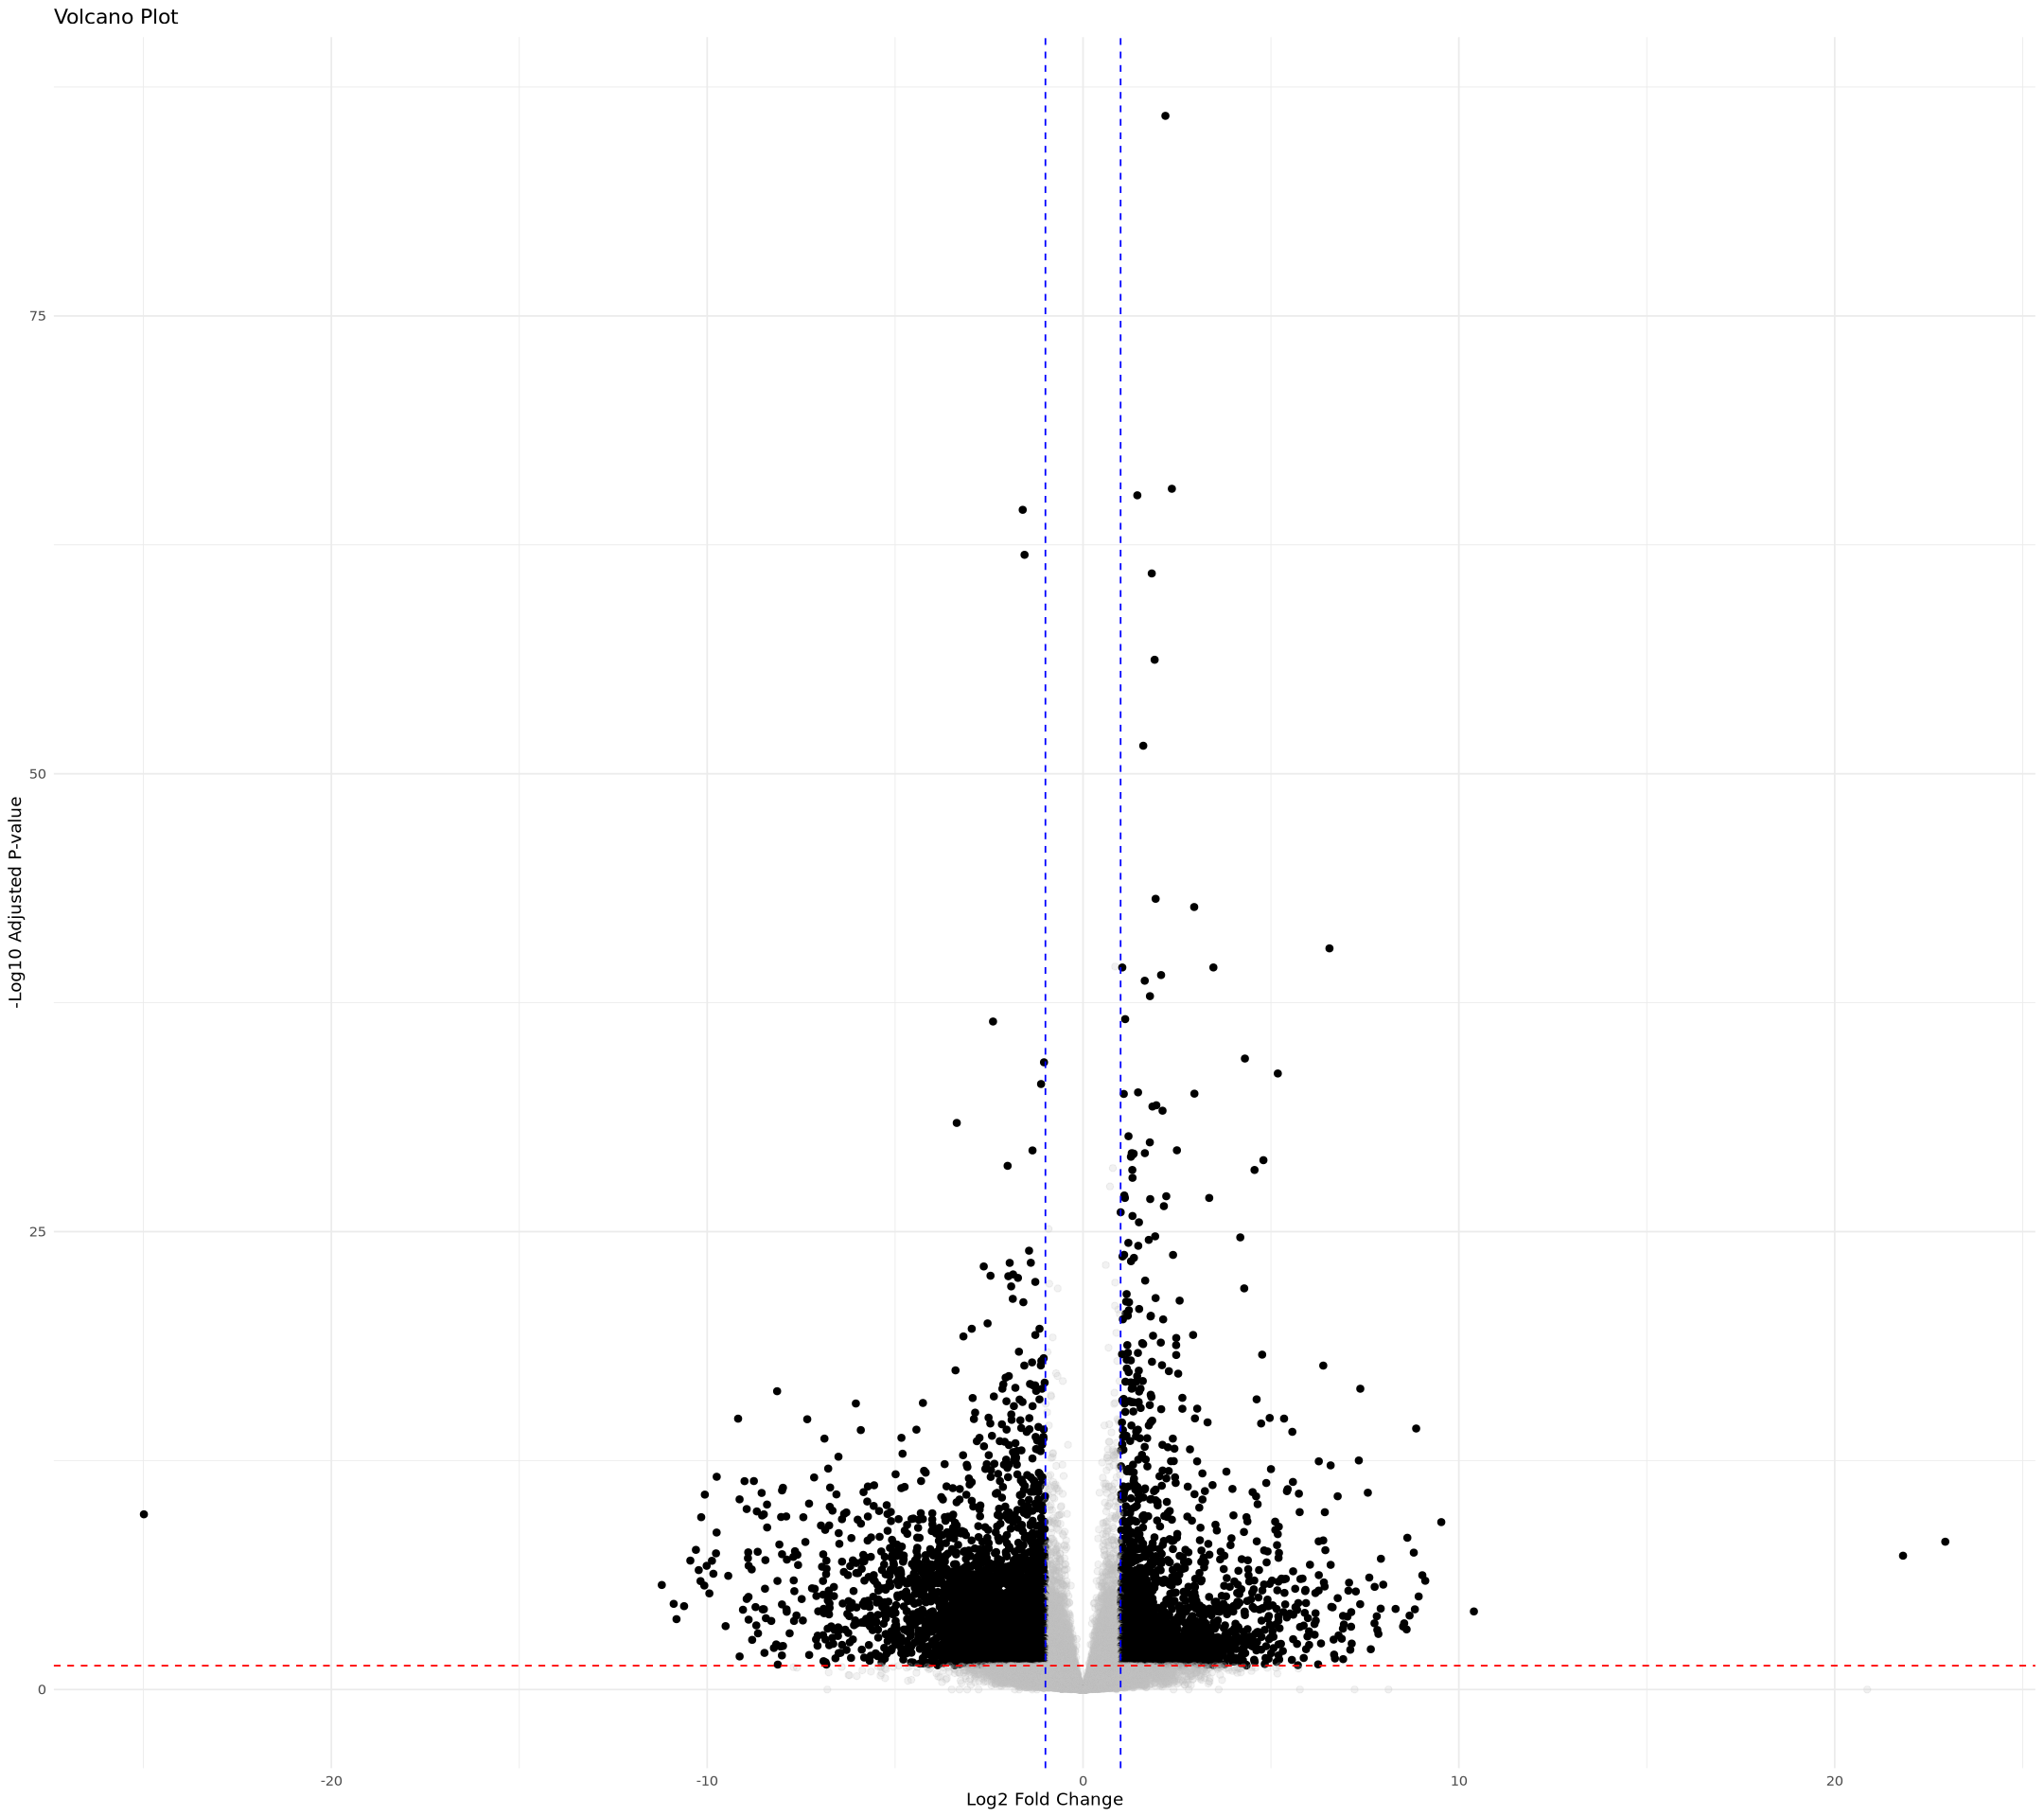

In [86]:
res$padj[is.na(res$padj)] <- 1
# Mark entries that are in res_filtered
res$IsFiltered <- res %in% res_filtered


# Plotting both filtered and unfiltered data
p_volcano <- ggplot(res, aes(x = log2FoldChange, y = -log10(padj), alpha = IsFiltered)) +
  geom_point(aes(color = IsFiltered), size = 1.75) +  # Color differentiation based on filter status
  scale_alpha_manual(values = c(0.2, 1)) +  # Set alpha transparency for non-filtered and filtered points
  scale_color_manual(values = c("grey", "black")) +  # Color grey for non-highlighted, black for highlighted
  theme_minimal() +
  xlab("Log2 Fold Change") +
  ylab("-Log10 Adjusted P-value") +
  ggtitle("Volcano Plot") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +  # Significance line for p-value
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "blue") +  # Fold change significance lines
  guides(alpha = "none", color = "none")  # Remove the legend for alpha and color
print(p_volcano)


In the next notebook, lets make sense of which genes are involved in this differential expression. We will need to bring more context to the gene names.

other draft code for further info

In [ ]:
res_2d <- results(
  dds,
  contrast = c("dev_stage", "2 days cold treatment", "no cold treatment")
)

res_4d <- results(
  dds,
  contrast = c("dev_stage", "4 days cold treatment", "no cold treatment")
)